<a href="https://colab.research.google.com/github/dragoa/MachineLearning/blob/main/DeepLearning%20AI/%5BSPZ%5D%20PyTorch%20for%20Deep%20Learning/Module%204/CNN_for_Nature_Classification_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Debugging, Inspection, and Modularization

In this notebook we are gonna investigate a broken Convolutional Neural Network (CNN) and use systematic debugging techniques to find and fix the bug. Also, we'll learn how to refactor the code for clarity and reuse, and finally, dissect a complex, pre-trained model to understand its inner workings.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.models import SqueezeNet
from torchvision import datasets

import os

## Data Loading
For this purpose we are gonna load the Fashion MNIST dataset, which consists of grayscale images of clothing items used for classification tasks.

In [2]:
def download_dataset():
  path = "/content/dataset"

  if not os.path.exists(path):
    os.makedirs(path)
    print("Downloading data...")

    datasets.FashionMNIST(path, train=False, download=True)
  else:
    print("The dataset is already downloaded")

  # Load the Fashion MNIST validation dataset
  dataset = datasets.FashionMNIST(path, train=False, download=False)

  return dataset

dataset = download_dataset()

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.54MB/s]


In [3]:
# Define transforms
transform = transforms.ToTensor()

dataset.transform = transform

In [4]:
batch_size = 64

# Create a DataLoader
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [5]:
img_batch, label_batch = next(iter(data_loader))

print(f"Batch shape: {img_batch.shape}")

Batch shape: torch.Size([64, 1, 28, 28])


## Debug the model

We are going to examine a simple CNN model and try to debug it as a cripric error will be raised.

In [6]:
class SimpleCNN(nn.Module):

  def __init__(self) :
    super().__init__()
    self.n_classes = 10

    # Convolutional block
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
    self.relu1 = nn.ReLU()
    self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    # Fully connected layer
    # Images are 28x28
    self.fc1 = nn.Linear(in_features=32*14*14, out_features=128)
    self.relu2 = nn.ReLU()
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = self.max_pool1(self.relu1(self.conv1(x)))
    x = self.relu2(self.fc1(x))
    x = self.fc2(x)

    return x


In [7]:
simple_cnn = SimpleCNN()

try:
  output = simple_cnn(img_batch)
except Exception as e:
  print(f"Error during forward pass {e}")

Error during forward pass mat1 and mat2 shapes cannot be multiplied (28672x14 and 6272x128)


The error message is quite criptic and we don't have any insights on where this might come from, so we need to debug further the forward method.

We are gonna define a new class that inherits from the original model and overrides the `forward` method to include print statements that display the shape of the tensor after each layer.
A first try might be to explicitly separate the layers in the `forward` method and, for each layer:
* print the shape of the tensor before the layer (input shape),
* print the shape of some *parameters of the layer* (e.g., weights and biases),
* print the shape of the *activation* tensor after the layer (output shape), which will be the input for the next layer.

In [8]:
class SimpleCNN_Debug(SimpleCNN):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    print(f"Input shape {x.shape} \n---")
    print("Convolutional layer parameters (weights, biases)\n", self.conv1.weight.shape, self.conv1.bias.shape)
    x_conv = self.relu1(self.conv1(x))

    print(f"Shape after relu\n {x_conv.shape}")
    x_pool = self.max_pool1(x_conv)
    print(f"Shape after pooling\n {x_pool.shape}")

    ### Solution
    x_pool = torch.flatten(x_pool, start_dim=1)
    print(f"Shape after flattening\n {x_pool.shape}")
    ###

    print("Linear layer parameters (weights, biases)\n", self.fc1.weight.shape, self.fc1.bias.shape)

    x_fc1 = self.relu2(self.fc1(x_pool))
    print(f"Shape after linear layer 1\n {x_fc1.shape}")
    print("Last layer parameters (weights, biases)\n", self.fc2.weight.shape, self.fc2.bias.shape)

    x_fc2 = self.relu2(self.fc2(x_fc1))
    print(f"Shape after linear layer 1\n {x_fc2.shape}")

    return x

In [9]:
simple_cnn_debug = SimpleCNN_Debug()

try:
  output = simple_cnn_debug(img_batch)
except Exception as e:
  print(f"Error during forward pass {e}")

###
#  Shape after pooling
#    torch.Size([64, 32, 14, 14])
#  Linear layer parameters (weights, biases)
#    torch.Size([128, 6272]) torch.Size([128])
#  Error during forward pass mat1 and mat2 shapes cannot be multiplied (28672x14 and 6272x128)
###

Input shape torch.Size([64, 1, 28, 28]) 
---
Convolutional layer parameters (weights, biases)
 torch.Size([32, 1, 3, 3]) torch.Size([32])
Shape after relu
 torch.Size([64, 32, 28, 28])
Shape after pooling
 torch.Size([64, 32, 14, 14])
Shape after flattening
 torch.Size([64, 6272])
Linear layer parameters (weights, biases)
 torch.Size([128, 6272]) torch.Size([128])
Shape after linear layer 1
 torch.Size([64, 128])
Last layer parameters (weights, biases)
 torch.Size([10, 128]) torch.Size([10])
Shape after linear layer 1
 torch.Size([64, 10])


**The error occurs in the fully connected block**, specifically at the first linear layer: `x_pool` has shape `[64, 32, 14, 14]`, but the linear layer expects an input of shape `[64, 6272]` (its weight matrix has shape `[128, 6272]`).

As the linear layer `fc1` expects a 2D input of shape `[batch_size, input_features]`, the `x_pool` is flattened to a 2D tensor with shape `[64*32*14, 14]` before being passed to `fc1`. This is not the intended shape, and it leads to the dimension mismatch error.

Once you have identified the issue, you can fix it by adding a flattening operation before the first linear layer in the `forward` method.

## Modularization of a nn

The model is now working correctly, but the `forward` method is quite verbose and repetitive.
To make the code cleaner and more modular, you can use `nn.Sequential` to define the convolutional and fully connected blocks.

In this way you gain several advantages:
* **Modularity**: Each block is defined as a separate module, making it easier to understand and modify.
* **Reusability**: You can easily reuse the blocks in other models or experiments.
* **Cleaner Code**: The `forward` method becomes much simpler, as it only needs to call the blocks sequentially.
* **Less Error-Prone**: By defining the blocks in one place, you reduce the chances of making mistakes when implementing the `forward` method.

In [10]:
class SimpleCNN_mod(nn.Module):

  def __init__(self):
    super().__init__()
    # Convolutional blocks
    self.conv = ConvBlock(in_channels=1, out_channels=32, kernel_size=3, padding=1)
    self.flatten = nn.Flatten()
    self.block = nn.Sequential(
        nn.Linear(32*14*14, 128),
        nn.ReLU(),
        nn.Linear(128, 10))

  def forward(self, x):
    print(x.shape)
    x = self.conv(x)
    print(f"Shape after conv block {x.shape}")
    x = self.flatten(x)
    print(f"Shape after flatten layer {x.shape}")
    print(f"Expected shape of linear layer {self.block[0].weight.shape}")

    x = self.block(x)
    print(f"Shape after sequential block {x.shape}")

    return x


class ConvBlock(nn.Module):
  """
  Define a custom nn that contains a convolutional layer
  """
  def __init__(self, in_channels, out_channels, kernel_size, padding):
    super().__init__()

    self.block = nn.Sequential(
        nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

  def forward(self, x):
    return self.block(x)


In [11]:
model = SimpleCNN_mod()

output = model(img_batch)

torch.Size([64, 1, 28, 28])
Shape after conv block torch.Size([64, 32, 14, 14])
Shape after flatten layer torch.Size([64, 6272])
Expected shape of linear layer torch.Size([128, 6272])
Shape after sequential block torch.Size([64, 10])


### Statistical Inspection of the Initialization

A common check when inspecting a model is to look at the statistics of some activations to ensure that they are within a reasonable range.

In [12]:
class SimpleCNN_modDebug(SimpleCNN_mod):

  def __init__(self):
    super().__init__()


  def forward(self, x):
    x = self.conv(x)
    x = self.flatten(x)

    print("After conv_block, the activation statistics are:")
    self.get_statistics(x)

    x = self.block(x)

    print("After fc_block, the activation statistics are:")
    self.get_statistics(x)

    return x


  def get_statistics(self, activations):
    """
    Print statistics of the network
    """
    mean = activations.mean().item()
    std = activations.std().item()
    min_val = activations.min().item()
    max_val = activations.max().item()

    print(f" Mean: {mean}")
    print(f" Std: {std}")
    print(f" Min: {min_val}")
    print(f" Max: {max_val}")

    return mean, std, min_val, max_val


In [13]:
simple_cnn_seq_debug = SimpleCNN_modDebug()

for idx, (img_batch, _) in enumerate(data_loader):
    if idx < 5:
        print(f"=== Batch {idx} ===")
        output_debug = simple_cnn_seq_debug(img_batch)

=== Batch 0 ===
After conv_block, the activation statistics are:
 Mean: 0.13842347264289856
 Std: 0.1653694361448288
 Min: 0.0
 Max: 1.1959311962127686
After fc_block, the activation statistics are:
 Mean: 0.04056848958134651
 Std: 0.057057417929172516
 Min: -0.1450584977865219
 Max: 0.15473443269729614
=== Batch 1 ===
After conv_block, the activation statistics are:
 Mean: 0.13850700855255127
 Std: 0.16885600984096527
 Min: 0.0
 Max: 1.2637795209884644
After fc_block, the activation statistics are:
 Mean: 0.03971225768327713
 Std: 0.05763376131653786
 Min: -0.1326107382774353
 Max: 0.16498631238937378
=== Batch 2 ===
After conv_block, the activation statistics are:
 Mean: 0.13862738013267517
 Std: 0.168693408370018
 Min: 0.0
 Max: 1.262709379196167
After fc_block, the activation statistics are:
 Mean: 0.0400763563811779
 Std: 0.05775554105639458
 Min: -0.12583065032958984
 Max: 0.15688824653625488
=== Batch 3 ===
After conv_block, the activation statistics are:
 Mean: 0.13886174559593

This is a sanity check to ensure that the model is initialized correctly and that the activations are not exploding or vanishing.
*Those issues can lead to poor training performance or convergence problems.*

In [14]:
# Count the total number of parameters
total_params = sum(p.numel() for p in simple_cnn_seq_debug.parameters())

print(f"Numeber of parameters: {total_params}")

Numeber of parameters: 804554


## Model Inspection

With the previous model working correctly, you will now inspect a pre-existing complex model from `torchvision.models`, such as `SqueezeNet`.

In this section you will make use of the inspection utilities provided by PyTorch to explore the model's architecture, layers, and parameters.
These inspection techniques are foundational for effective debugging and for making informed modifications to your neural network designs.

In [15]:
squeeze_net = SqueezeNet()

print(squeeze_net)

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

In [16]:
# Iterate through the main blocks to print them
for name, block in squeeze_net.named_children():
    print(f"Block {name} has a total of {len(list(block.children()))} layers:")

    # List all children layers in the block
    for idx, layer in enumerate(block.children()):
        # Check if the layer is terminal (no children) or not
        if len(list(layer.children())) == 0:
            print(f"\t {idx} - Layer {layer}")
        # If the layer has children, it's a sub-block, then print only the number of children and its name
        else:
            layer_name = layer._get_name()  # More user-friendly name
            print(f"\t {idx} - Sub-block {layer_name} with {len(list(layer.children()))} layers")

Block features has a total of 13 layers:
	 0 - Layer Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
	 1 - Layer ReLU(inplace=True)
	 2 - Layer MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
	 3 - Sub-block Fire with 6 layers
	 4 - Sub-block Fire with 6 layers
	 5 - Sub-block Fire with 6 layers
	 6 - Layer MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
	 7 - Sub-block Fire with 6 layers
	 8 - Sub-block Fire with 6 layers
	 9 - Sub-block Fire with 6 layers
	 10 - Sub-block Fire with 6 layers
	 11 - Layer MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
	 12 - Sub-block Fire with 6 layers
Block classifier has a total of 4 layers:
	 0 - Layer Dropout(p=0.5, inplace=False)
	 1 - Layer Conv2d(512, 1000, kernel_size=(1, 1), stride=(1, 1))
	 2 - Layer ReLU(inplace=True)
	 3 - Layer AdaptiveAvgPool2d(output_size=(1, 1))


We can now print the first Fire sub block and see what there is inside

In [17]:
first_fire_module = squeeze_net.features[3]

for idx, module in enumerate(first_fire_module.modules()):
    # Avoid printing the top-level module itself
    if idx > 0 :
        print(module)

Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
ReLU(inplace=True)
Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
ReLU(inplace=True)
Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
ReLU(inplace=True)


### Detail Inspection

In [18]:
# Count the number of convolutional layers inside sqeeze net
type_layer = nn.Conv2d

selected_layers = [layer for layer in squeeze_net.modules() if isinstance(layer, type_layer)]

print(f"Number of {type_layer.__name__}: {len(selected_layers)}")

Number of Conv2d: 26


In [19]:
# Count the total number of parameters
total_params = sum(p.numel() for p in squeeze_net.parameters())

print(f"Numeber of parameters: {total_params}")

Numeber of parameters: 1248424


Now, you can take this further by inspecting the parameters of each terminal layer (layers without children) in the model.
For each terminal layer, you will print its name and the total number of parameters it contains.
This helps to identify which layers contribute most to the model's parameter count and can be useful for model optimization, pruning, or understanding where the model's capacity lies.

In [20]:
counting_params = {}

# For each terminal layer print its number of parameters
for layer in squeeze_net.named_modules():
    n_children = len(list(layer[1].children()))
    if n_children == 0:  # Terminal layer
        layer_name = layer[0]
        n_parameters = sum(p.numel() for p in layer[1].parameters())
        counting_params[layer_name] = n_parameters
        print(f"Layer {layer_name} has {n_parameters} parameters")

Layer features.0 has 14208 parameters
Layer features.1 has 0 parameters
Layer features.2 has 0 parameters
Layer features.3.squeeze has 1552 parameters
Layer features.3.squeeze_activation has 0 parameters
Layer features.3.expand1x1 has 1088 parameters
Layer features.3.expand1x1_activation has 0 parameters
Layer features.3.expand3x3 has 9280 parameters
Layer features.3.expand3x3_activation has 0 parameters
Layer features.4.squeeze has 2064 parameters
Layer features.4.squeeze_activation has 0 parameters
Layer features.4.expand1x1 has 1088 parameters
Layer features.4.expand1x1_activation has 0 parameters
Layer features.4.expand3x3 has 9280 parameters
Layer features.4.expand3x3_activation has 0 parameters
Layer features.5.squeeze has 4128 parameters
Layer features.5.squeeze_activation has 0 parameters
Layer features.5.expand1x1 has 4224 parameters
Layer features.5.expand1x1_activation has 0 parameters
Layer features.5.expand3x3 has 36992 parameters
Layer features.5.expand3x3_activation has 

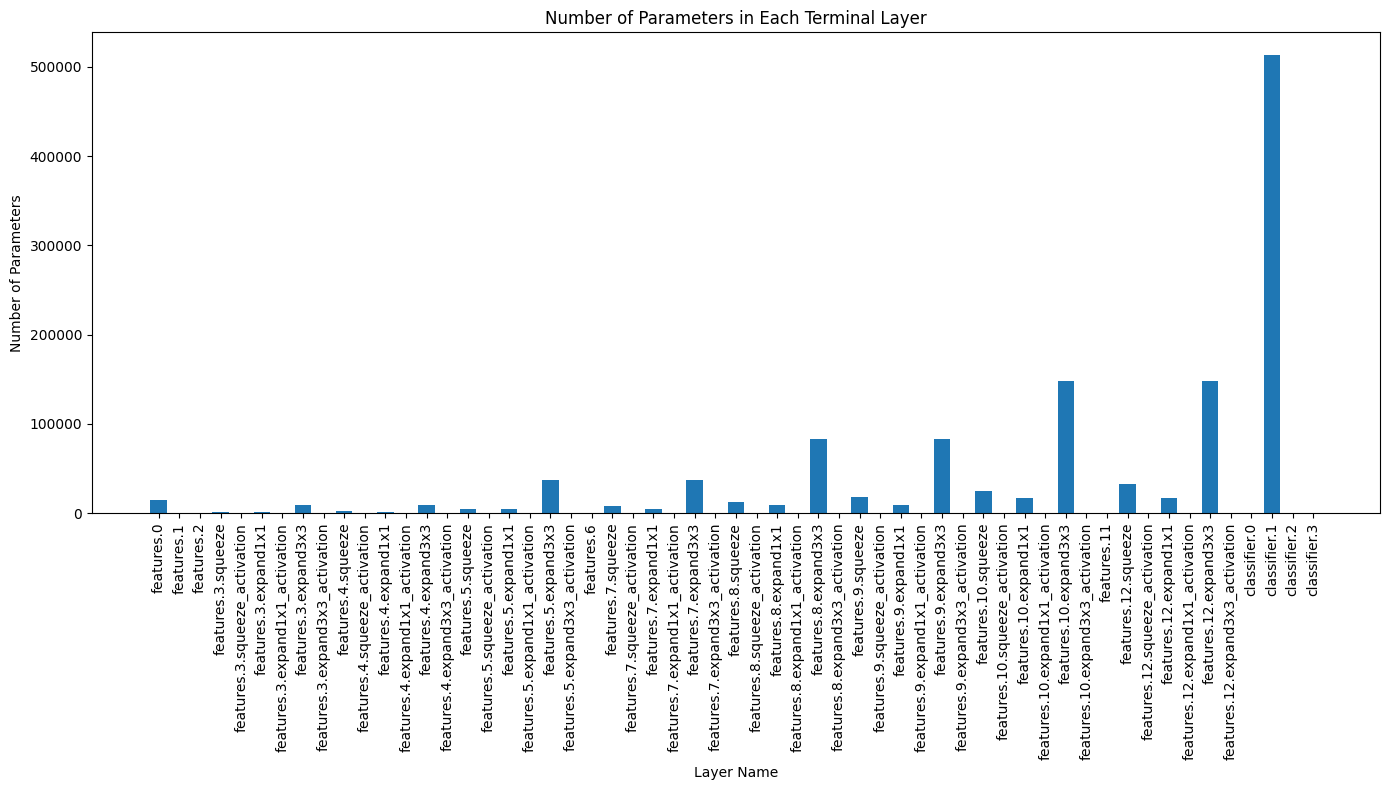

In [21]:
def plot_counting(counting_params):
    import matplotlib.pyplot as plt

    # Plotting
    plt.figure(figsize=(14, 8))
    plt.bar(counting_params.keys(), counting_params.values())
    plt.xlabel("Layer Name")
    plt.ylabel("Number of Parameters")
    plt.title("Number of Parameters in Each Terminal Layer")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


# Plotting the distribution of parameters per layer
plot_counting(counting_params)